# Phân tích kết quả thí nghiệm Blocks World

Phân tích và so sánh hai phương pháp lập kế hoạch: **LLM-only** và **LLM+Planner**.

## 1. Setup & Load Data


In [2]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

ROOT_DIR = Path("..")
SRC_DIR = ROOT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

METRICS_PATH = ROOT_DIR / "results" / "metrics.csv"
BOOLEAN_COLUMNS = ["success", "parse_success", "plan_valid", "goal_achieved"]

df = pd.read_csv(
    METRICS_PATH,
    dtype={col: "string" for col in BOOLEAN_COLUMNS},
)

for col in BOOLEAN_COLUMNS:
    df[col] = df[col].map({"True": True, "False": False, "1": True, "0": False})

print(f"Số rows: {len(df)}")
print(f"Số bài toán unique: {df['id'].nunique()}")
print(f"Số phương pháp unique: {df['method'].nunique()}")
display(df.head(10))

Số rows: 80
Số bài toán unique: 40
Số phương pháp unique: 2


,id,difficulty,method,parse_success,planner_success,plan_valid,goal_achieved,success,plan_length,runtime,error_type
0,bw_easy_001,easy,llm_only,True,NaN,True,True,True,2,22.7441,NaN
1,bw_easy_002,easy,llm_only,True,NaN,False,False,False,3,4.8018,precondition_violation
2,bw_easy_003,easy,llm_only,True,NaN,False,False,False,3,5.0894,precondition_violation
3,bw_easy_004,easy,llm_only,True,NaN,False,False,False,3,4.8142,precondition_violation
4,bw_easy_005,easy,llm_only,True,NaN,True,True,True,2,3.8677,NaN
5,bw_easy_006,easy,llm_only,True,NaN,False,False,False,3,4.6967,precondition_violation
6,bw_easy_007,easy,llm_only,True,NaN,False,False,False,2,3.8357,unknown_object
7,bw_easy_008,easy,llm_only,True,NaN,False,False,False,3,5.1948,precondition_violation
8,bw_easy_009,easy,llm_only,True,NaN,False,False,False,3,5.5814,precondition_violation
9,bw_easy_010,easy,llm_only,True,NaN,False,False,False,1,3.5427,precondition_violation


## 2. Tổng quan Dataset

Phần này kiểm tra phân bố bài toán theo độ khó, số lượt chạy theo phương pháp, và mức độ cân bằng của thiết kế thí nghiệm.

In [3]:
difficulty_order = ["easy", "medium", "hard"]
method_order = ["llm_only", "llm_planner"]

problems_by_difficulty = (
    df[["id", "difficulty"]]
    .drop_duplicates()
    .groupby("difficulty")
    .size()
    .reindex(difficulty_order, fill_value=0)
    .rename("problem_count")
    .reset_index()
)

runs_by_method = (
    df.groupby("method")
    .size()
    .reindex(method_order, fill_value=0)
    .rename("run_count")
    .reset_index()
)

runs_pivot = (
    df.groupby(["difficulty", "method"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=difficulty_order, columns=method_order, fill_value=0)
)

dataset_summary = runs_pivot.rename(
    columns={"llm_only": "llm_only_runs", "llm_planner": "llm_planner_runs"}
)
dataset_summary.insert(0, "total_runs", dataset_summary.sum(axis=1))
dataset_summary = dataset_summary.reset_index()

display(Markdown("### Số bài toán theo difficulty"))
display(problems_by_difficulty)
display(Markdown("### Số runs theo method"))
display(runs_by_method)
display(Markdown("### Bảng tổng hợp runs"))
display(dataset_summary)

### Số bài toán theo difficulty

,difficulty,problem_count
0,easy,10
1,medium,15
2,hard,15


### Số runs theo method

,method,run_count
0,llm_only,40
1,llm_planner,40


### Bảng tổng hợp runs

method,difficulty,total_runs,llm_only_runs,llm_planner_runs
0,easy,20,10,10
1,medium,30,15,15
2,hard,30,15,15


## 3. Success Rate Analysis

Tính success rate tổng thể theo phương pháp và theo từng mức độ khó. Các giá trị được định dạng dưới dạng phần trăm để dễ so sánh.

In [4]:
success_by_method = (
    df.groupby("method", as_index=False)["success"]
    .mean()
    .rename(columns={"success": "success_rate"})
)

success_by_difficulty = (
    df.pivot_table(
        index="difficulty",
        columns="method",
        values="success",
        aggfunc="mean",
    )
    .reindex(index=difficulty_order, columns=method_order)
)

method_rates = success_by_method.set_index("method")["success_rate"]
better_method = method_rates.idxmax()
difficulty_gap = success_by_difficulty.max(axis=1) - success_by_difficulty.min(axis=1)
largest_gap_difficulty = difficulty_gap.idxmax()

display(Markdown("### Success rate theo method"))
display(success_by_method.style.format({"success_rate": "{:.1%}"}))
display(Markdown("### Success rate theo difficulty × method"))
display(success_by_difficulty.style.format("{:.1%}"))

### Success rate theo method

,method,success_rate
0,llm_only,12.5%
1,llm_planner,75.0%


### Success rate theo difficulty × method

method,llm_only,llm_planner
difficulty,,
easy,20.0%,100.0%
medium,20.0%,60.0%
hard,0.0%,73.3%


## 4. Visualizations


### Success rate theo phương pháp

Biểu đồ so sánh tỷ lệ thành công tổng thể giữa LLM-only và LLM+Planner.

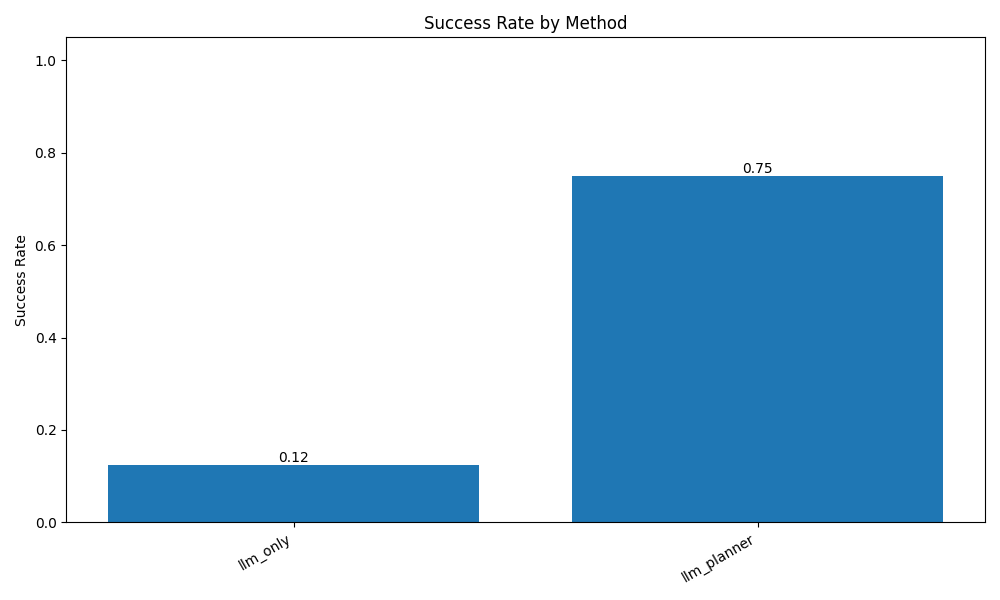

In [5]:
display(Image(filename=str(ROOT_DIR / "results" / "figures" / "success_rate_by_method.png")))

### Success rate theo độ khó

Biểu đồ thể hiện mức độ ổn định của mỗi phương pháp trên các nhóm easy, medium, và hard.

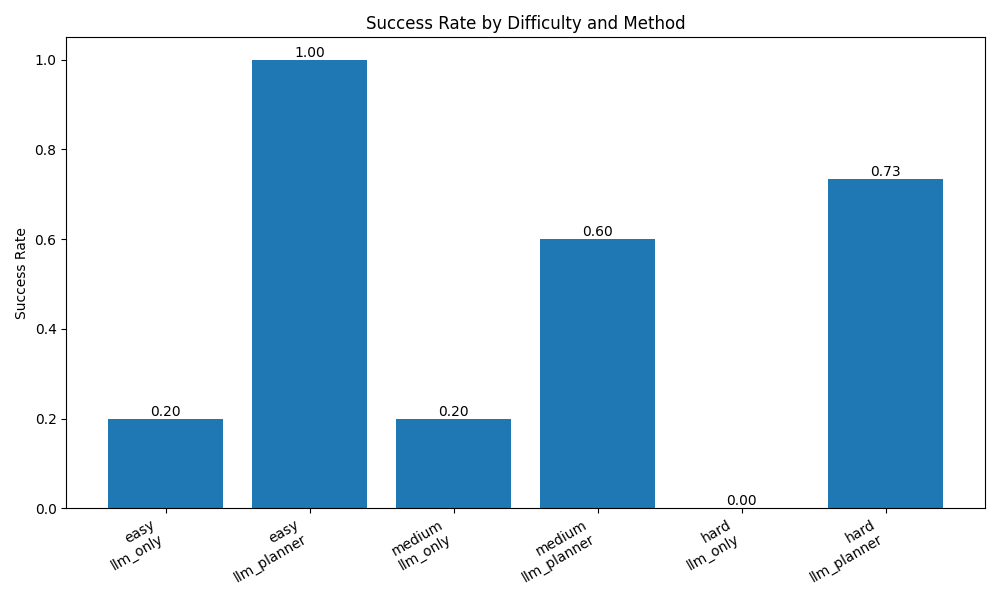

In [6]:
display(Image(filename=str(ROOT_DIR / "results" / "figures" / "success_rate_by_difficulty.png")))

### Phân bố lỗi

Biểu đồ tổng hợp các nhóm lỗi xuất hiện trong những lượt chạy không thành công.

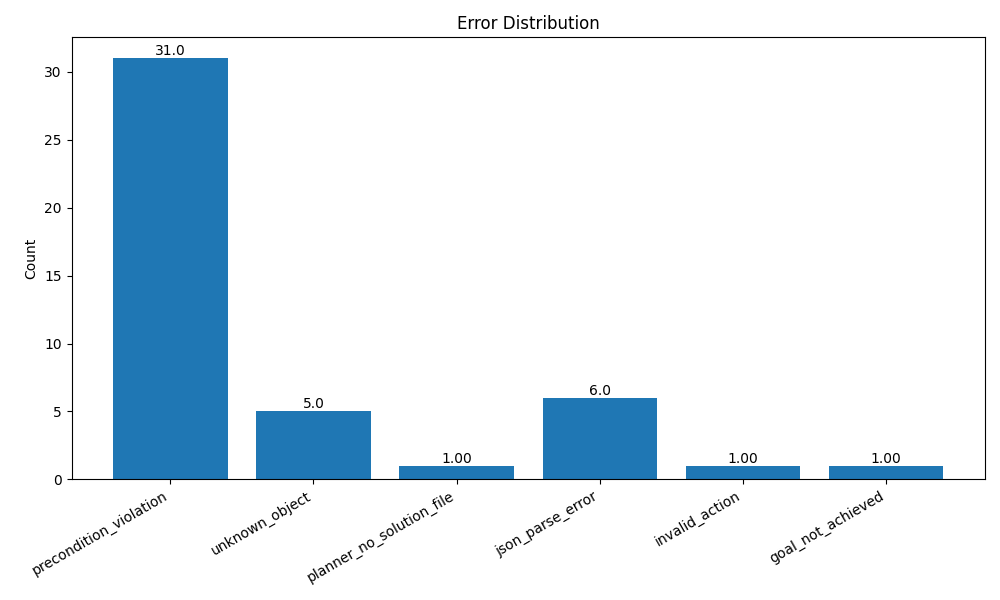

In [7]:
display(Image(filename=str(ROOT_DIR / "results" / "figures" / "error_distribution.png")))

### Độ dài kế hoạch trung bình

Biểu đồ so sánh số action trung bình trong kế hoạch do hai phương pháp tạo ra.

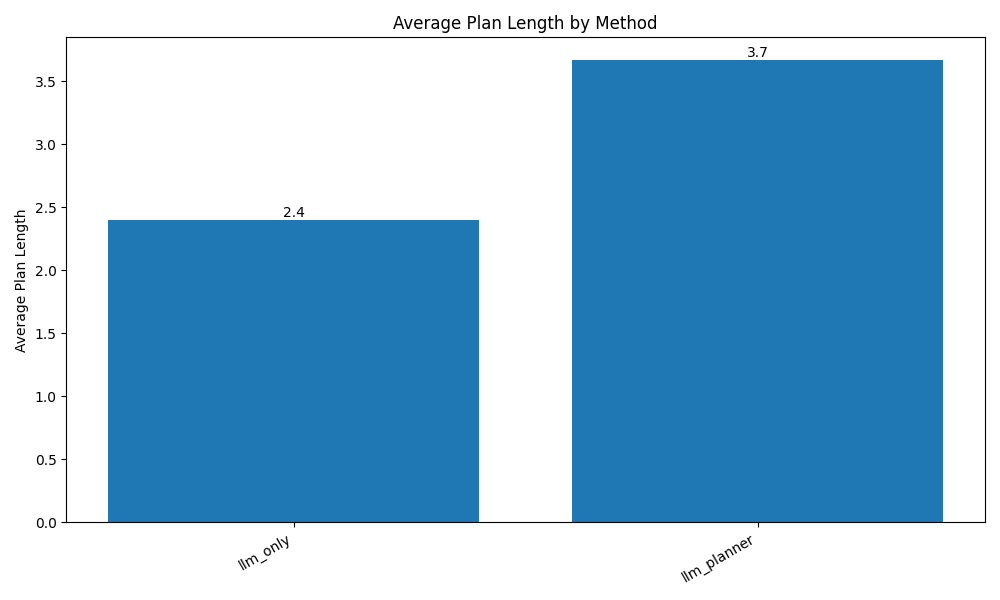

In [8]:
display(Image(filename=str(ROOT_DIR / "results" / "figures" / "avg_plan_length.png")))

## 5. Error Analysis

Lọc các lượt chạy thất bại, chuẩn hóa `error_type` bằng cách chỉ giữ phần trước dấu `:`, rồi đếm lỗi theo từng phương pháp.

In [9]:
failed_df = df.loc[df["success"].eq(False)].copy()
failed_df["error_type_normalized"] = (
    failed_df["error_type"]
    .fillna("")
    .astype(str)
    .str.split(":", n=1)
    .str[0]
    .str.strip()
    .replace("", "unknown_error")
)

error_crosstab = pd.crosstab(
    failed_df["error_type_normalized"],
    failed_df["method"],
).reindex(columns=method_order, fill_value=0)

most_common_error_by_method = {}
for method in method_order:
    method_errors = failed_df.loc[
        failed_df["method"].eq(method), "error_type_normalized"
    ].value_counts()
    most_common_error_by_method[method] = (
        method_errors.idxmax() if not method_errors.empty else "không có lỗi"
    )

display(error_crosstab)

error_notes = "\n".join(
    f"- Lỗi phổ biến nhất của **{method}**: `{error_type}`."
    for method, error_type in most_common_error_by_method.items()
)
display(Markdown(f"### Nhận xét\n\n{error_notes}"))

method,llm_only,llm_planner
error_type_normalized,,
goal_not_achieved,0,1
invalid_action,1,0
json_parse_error,0,6
planner_no_solution_file,0,1
precondition_violation,29,2
unknown_object,5,0


### Nhận xét

- Lỗi phổ biến nhất của **llm_only**: `precondition_violation`.
- Lỗi phổ biến nhất của **llm_planner**: `json_parse_error`.

In [10]:
planner_rate = method_rates.get("llm_planner", float("nan"))
llm_only_rate = method_rates.get("llm_only", float("nan"))
llm_only_error = most_common_error_by_method.get("llm_only", "không có lỗi")
llm_planner_error = most_common_error_by_method.get("llm_planner", "không có lỗi")

conclusion = f"""
**LLM+Planner đạt success rate {planner_rate:.1%} so với {llm_only_rate:.1%} của LLM-only.**

Chênh lệch lớn nhất ở độ khó **{largest_gap_difficulty}**.

Lỗi phổ biến nhất của llm_only: `{llm_only_error}`.

Lỗi phổ biến nhất của llm_planner: `{llm_planner_error}`.
"""

display(Markdown(conclusion))


**LLM+Planner đạt success rate 75.0% so với 12.5% của LLM-only.**

Chênh lệch lớn nhất ở độ khó **easy**.

Lỗi phổ biến nhất của llm_only: `precondition_violation`.

Lỗi phổ biến nhất của llm_planner: `json_parse_error`.
